# UMAP de ESQAD con cuatro representaciones

Este notebook compara la estructura del dataset ESQAD con cuatro representaciones distintas:

- Bag of Words (`BoW`).
- Embeddings `nomic-embed-text` servidos por Ollama.
- Embeddings `qwen3-embedding` servidos por Ollama.
- TF-IDF.

El objetivo es ver cómo cambia la geometría de los datos cuando cambia la representación vectorial.

In [10]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

In [11]:
# Resolver el root del repositorio y cargar las utilidades locales
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation" / "datasets.py").exists()),
        CANDIDATE_ROOT,
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib.util


def load_local_module(module_name: str, file_path: Path, *, is_package: bool = False):
    spec = importlib.util.spec_from_file_location(
        module_name,
        file_path,
        submodule_search_locations=[str(file_path.parent)] if is_package else None,
    )
    if spec is None or spec.loader is None:
        raise ImportError(f"No se pudo cargar {module_name} desde {file_path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


load_local_module("validation", ROOT / "validation" / "__init__.py", is_package=True)
load_local_module(
    "validation.representation",
    ROOT / "validation" / "representation" / "__init__.py",
    is_package=True,
)
local_datasets = load_local_module("validation.datasets", ROOT / "validation" / "datasets.py")
local_bow = load_local_module(
    "validation.representation.bow",
    ROOT / "validation" / "representation" / "bow.py",
)
local_ollama = load_local_module(
    "validation.representation.ollama_embeddings",
    ROOT / "validation" / "representation" / "ollama_embeddings.py",
)
local_tfidf = load_local_module(
    "validation.representation.tfidf",
    ROOT / "validation" / "representation" / "tfidf.py",
)

DatasetLoader = local_datasets.DatasetLoader
BoWVectorizer = local_bow.BoWVectorizer
OllamaEmbeddings = local_ollama.OllamaEmbeddings
TFIDFVectorizer = local_tfidf.TFIDFVectorizer

EDA_DIR = ROOT / "validation" / "results" / "esquad_umap"
TABLES_DIR = EDA_DIR / "tables"
FIGURES_DIR = EDA_DIR / "figures"
CACHE_DIR = EDA_DIR / "cache"
for path in [EDA_DIR, TABLES_DIR, FIGURES_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados: {EDA_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/esquad_umap


In [12]:
# Cargar y limpiar ESQAD
loader = DatasetLoader()
df = loader.load_esquad().copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Filas limpias: {len(df)}")
display(df.head())

Loading ESQAD (Spanish)...
Filas limpias: 1184


,text,label
0,¿Cuántos puntos dejaron escapar en defensa los...,Education_ES
1,¿Cuántas capturas ha conseguido Jared Allen en...,Education_ES
2,¿Cuántos derribos se anotó Luke Kuechly?,Education_ES
3,¿Cuántos balones interceptó Josh Norman?,Education_ES
4,¿Quién de todo el equipo ha conseguido más cap...,Education_ES


In [13]:
# Usar una muestra controlada para que el notebook sea más rápido y comparable
SAMPLE_SIZE = min(500, len(df))
if SAMPLE_SIZE < len(df):
    df_eval = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_eval = df.copy().reset_index(drop=True)

df_eval["char_len"] = df_eval["text"].str.len()
df_eval["tok_len"] = df_eval["text"].str.findall(r"\w+").str.len()
df_eval.to_csv(TABLES_DIR / "esquad_umap_sample.csv", index=False, encoding="utf-8")

texts = df_eval["text"].tolist()
print(f"Muestra usada: {len(df_eval)}")
display(df_eval[["text", "char_len", "tok_len"]].head())

Muestra usada: 500


,text,char_len,tok_len
0,"En Estados Unidos, ¿cuál es la velocidad habit...",90,16
1,¿Cuándo visitó Obama a Kenia finalmente?,40,6
2,¿Como qué libro fueron publicadas las siete co...,76,12
3,¿Qué porcentaje de la población de Varsovia er...,68,11
4,¿Qué sucedió cuando se asimilaron las cianobac...,53,7


In [15]:
# Construir las representaciones
bow_vectorizer = BoWVectorizer(max_features=2000, min_df=2)
tfidf_vectorizer = TFIDFVectorizer(max_features=2000, min_df=2)

X_bow = bow_vectorizer.fit_transform(texts).astype(np.float32)
X_tfidf = tfidf_vectorizer.fit_transform(texts).astype(np.float32)

ollama_host = os.getenv("OLLAMA_HOST", "localhost")
ollama_port = int(os.getenv("OLLAMA_PORT", "11434"))
nomic_embedder = OllamaEmbeddings(model="nomic-embed-text", host=ollama_host, port=ollama_port)
qwen_embedder = OllamaEmbeddings(model="qwen3-embedding:0.6b", host=ollama_host, port=ollama_port)
nomic_cache = CACHE_DIR / f"nomic_embeddings_n{len(texts)}.npy"
qwen_cache = CACHE_DIR / f"qwen3_embeddings_n{len(texts)}.npy"

if nomic_cache.exists():
    X_nomic = np.load(nomic_cache)
else:
    try:
        X_nomic = nomic_embedder.embed_batch(texts).astype(np.float32)
        np.save(nomic_cache, X_nomic)
    except Exception as exc:
        raise RuntimeError(
            f"No se pudieron generar los embeddings de Ollama. Revisa {ollama_host}:{ollama_port} y que el modelo '{nomic_embedder.model}' esté disponible.",
        ) from exc

if qwen_cache.exists():
    X_qwen = np.load(qwen_cache)
else:
    try:
        X_qwen = qwen_embedder.embed_batch(texts).astype(np.float32)
        np.save(qwen_cache, X_qwen)
    except Exception as exc:
        raise RuntimeError(
            f"No se pudieron generar los embeddings de Ollama. Revisa {ollama_host}:{ollama_port} y que el modelo '{qwen_embedder.model}' esté disponible.",
        ) from exc

print("BoW:", X_bow.shape)
print("TF-IDF:", X_tfidf.shape)
print("Nomic:", X_nomic.shape)
print("Qwen3:", X_qwen.shape)

BoW: (500, 314)
TF-IDF: (500, 314)
Nomic: (500, 768)
Qwen3: (500, 1024)


In [16]:
# Proyectar cada representación a 2D con UMAP
umap_kwargs = {
    "n_components": 2,
    "n_neighbors": 15,
    "min_dist": 0.15,
    "metric": "cosine",
    "random_state": 42,
}

def project_representation(name: str, matrix: np.ndarray) -> pd.DataFrame:
    reducer = UMAP(**umap_kwargs)
    coords = reducer.fit_transform(matrix)
    out = df_eval[["text", "char_len", "tok_len"]].copy()
    out["representation"] = name
    out["umap_1"] = coords[:, 0]
    out["umap_2"] = coords[:, 1]
    out.to_csv(TABLES_DIR / f"{name}_umap.csv", index=False, encoding="utf-8")
    return out

proj_bow = project_representation("bow", X_bow)
proj_nomic = project_representation("nomic", X_nomic)
proj_qwen = project_representation("qwen3", X_qwen)
proj_tfidf = project_representation("tfidf", X_tfidf)

display(proj_bow.head())

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,text,char_len,tok_len,representation,umap_1,umap_2
0,"En Estados Unidos, ¿cuál es la velocidad habit...",90,16,bow,15.816843,38.180607
1,¿Cuándo visitó Obama a Kenia finalmente?,40,6,bow,15.776773,38.947342
2,¿Como qué libro fueron publicadas las siete co...,76,12,bow,15.730121,38.309769
3,¿Qué porcentaje de la población de Varsovia er...,68,11,bow,15.771503,37.995392
4,¿Qué sucedió cuando se asimilaron las cianobac...,53,7,bow,15.992181,38.773952


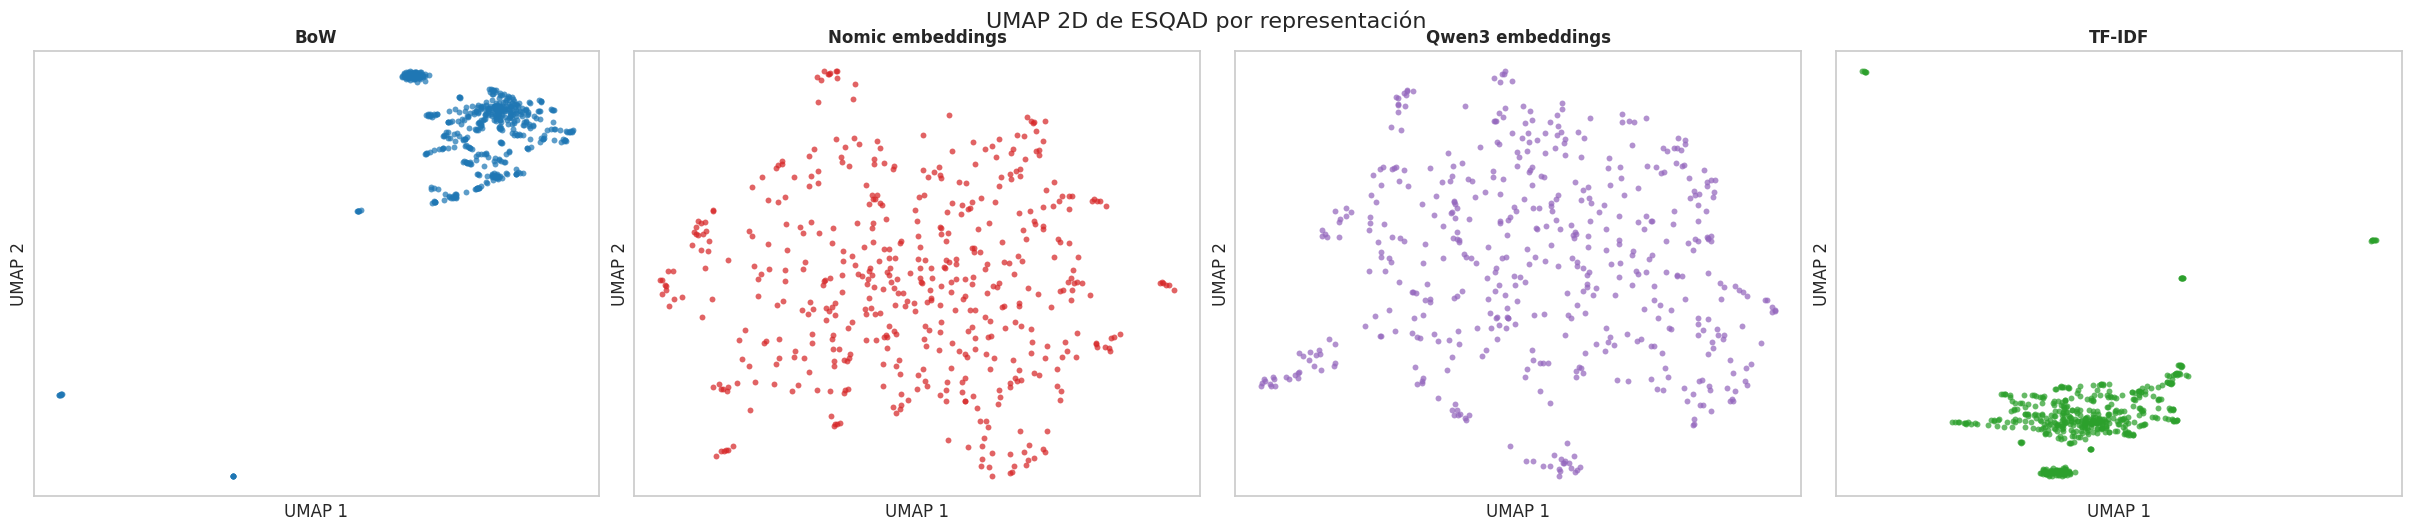

In [18]:
# Comparativa visual UMAP
palette = {
    "bow": "#1f77b4",
    "nomic": "#d62728",
    "qwen3": "#9467bd",
    "tfidf": "#2ca02c",
}
plots = [
    (proj_bow, "BoW"),
    (proj_nomic, "Nomic embeddings"),
    (proj_qwen, "Qwen3 embeddings"),
    (proj_tfidf, "TF-IDF"),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
for ax, (proj, title) in zip(axes, plots):
    sns.scatterplot(
        data=proj,
        x="umap_1",
        y="umap_2",
        ax=ax,
        s=18,
        alpha=0.72,
        color=palette[proj["representation"].iloc[0]],
        linewidth=0,
        edgecolor=None,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("UMAP 2D de ESQAD por representación", fontsize=16, y=1.03)
fig.savefig(FIGURES_DIR / "umap_four_representations.png", dpi=180, bbox_inches="tight")
plt.show()

Puntos totales (BoW): 500
Puntos inliers: 475
Puntos outliers: 25


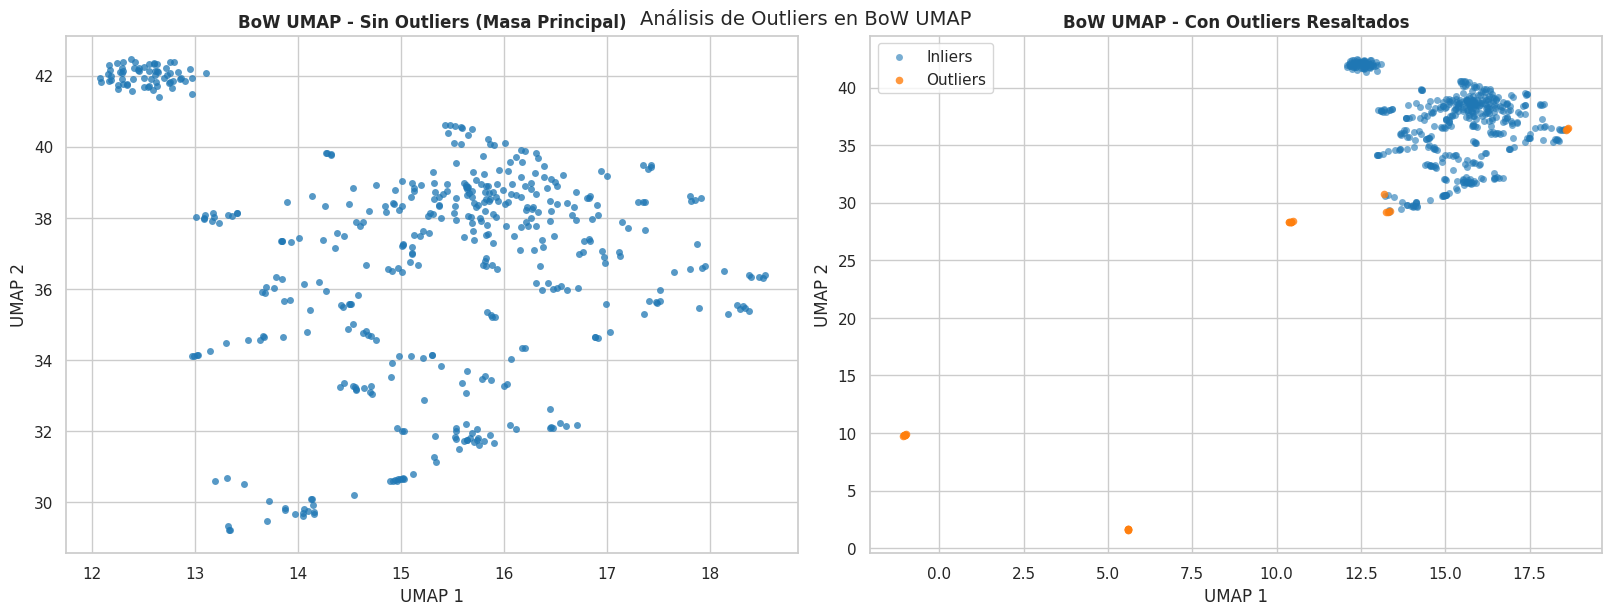

In [19]:
from sklearn.ensemble import IsolationForest

# Detectar outliers en BoW UMAP usando Isolation Forest
X_umap_bow = proj_bow[["umap_1", "umap_2"]].values
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # 5% outliers
outlier_labels = iso_forest.fit_predict(X_umap_bow)

# Filtrar datos: inliers solo
proj_bow_inliers = proj_bow[outlier_labels == 1].copy()
proj_bow_outliers = proj_bow[outlier_labels == -1].copy()

print(f"Puntos totales (BoW): {len(proj_bow)}")
print(f"Puntos inliers: {len(proj_bow_inliers)}")
print(f"Puntos outliers: {len(proj_bow_outliers)}")

# Visualizar BoW sin outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Izquierda: Solo inliers (masa principal)
sns.scatterplot(
    data=proj_bow_inliers,
    x="umap_1",
    y="umap_2",
    ax=axes[0],
    s=25,
    alpha=0.75,
    color="#1f77b4",
    linewidth=0,
    edgecolor=None,
)
axes[0].set_title("BoW UMAP - Sin Outliers (Masa Principal)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Derecha: Inliers + outliers para comparación
sns.scatterplot(
    data=proj_bow_inliers,
    x="umap_1",
    y="umap_2",
    ax=axes[1],
    s=25,
    alpha=0.60,
    color="#1f77b4",
    label="Inliers",
    linewidth=0,
    edgecolor=None,
)
sns.scatterplot(
    data=proj_bow_outliers,
    x="umap_1",
    y="umap_2",
    ax=axes[1],
    s=30,
    alpha=0.8,
    color="#ff7f0e",
    label="Outliers",
    linewidth=0,
    edgecolor=None,
)
axes[1].set_title("BoW UMAP - Con Outliers Resaltados", fontweight="bold", fontsize=12)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

fig.suptitle("Análisis de Outliers en BoW UMAP", fontsize=14, y=1.00)
fig.savefig(FIGURES_DIR / "bow_umap_outlier_analysis.png", dpi=180, bbox_inches="tight")
plt.show()